<a href="https://colab.research.google.com/github/SoumajyotiDhut/rare-disease-identification-system/blob/main/notebooks/colab/Day_2_EDA_NLP_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import pickle
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

BASE  = "/content/drive/MyDrive/rare_disease_project"
DATA  = f"{BASE}/data"
RESULTS = f"{BASE}/results"
MODELS  = f"{BASE}/models"
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(MODELS,  exist_ok=True)

# Load main dataset
df = pd.read_csv(f"{DATA}/clean_multimodal_samples.csv")

# Load splits
with open(f"{DATA}/splits/exp1_train.pkl", "rb") as f:
    exp1_train = pickle.load(f)
with open(f"{DATA}/splits/full_train.pkl", "rb") as f:
    full_train = pickle.load(f)
with open(f"{DATA}/splits/full_test.pkl", "rb") as f:
    full_test = pickle.load(f)

# Load tiers
with open(f"{DATA}/clean_tiers.pkl", "rb") as f:
    tiers = pickle.load(f)

# Load label encoder
with open(f"{DATA}/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

print("✓ All files loaded")
print(f"  Full dataset : {df.shape}")
print(f"  Exp1 train   : {exp1_train.shape}")
print(f"  Full train   : {full_train.shape}")
print(f"  Full test    : {full_test.shape}")
print(f"  Classes      : {len(le.classes_)}")

Mounted at /content/drive
✓ All files loaded
  Full dataset : (36487, 9)
  Exp1 train   : (514, 11)
  Full train   : (18431, 11)
  Full test    : (5339, 11)
  Classes      : 795


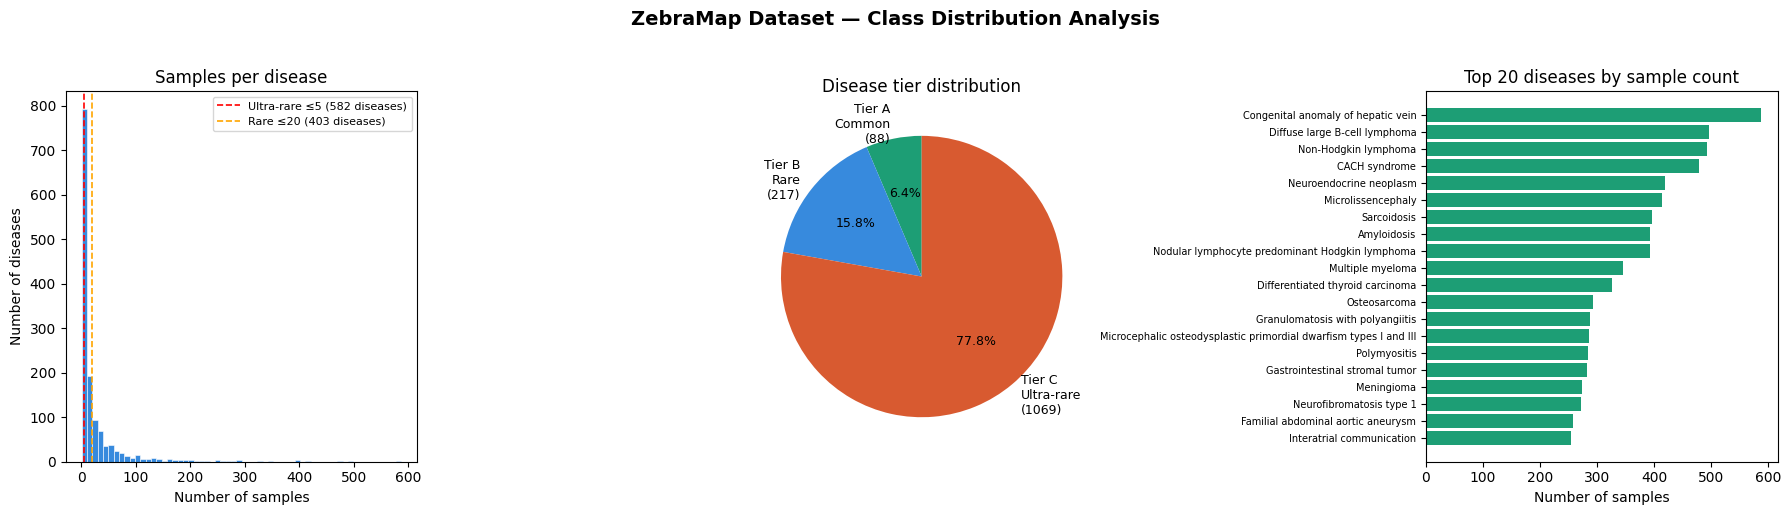

✓ Plot 1 saved


In [2]:
disease_counts = df['disease_name'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ZebraMap Dataset — Class Distribution Analysis',
             fontsize=14, fontweight='bold', y=1.02)

# Plot 1 — Histogram of samples per disease
axes[0].hist(disease_counts.values, bins=60,
             color='#378ADD', edgecolor='white', linewidth=0.4)
axes[0].axvline(x=5,  color='red',    linestyle='--', linewidth=1.2,
                label=f'Ultra-rare ≤5 ({(disease_counts<=5).sum()} diseases)')
axes[0].axvline(x=20, color='orange', linestyle='--', linewidth=1.2,
                label=f'Rare ≤20 ({((disease_counts>5)&(disease_counts<=20)).sum()} diseases)')
axes[0].set_title('Samples per disease')
axes[0].set_xlabel('Number of samples')
axes[0].set_ylabel('Number of diseases')
axes[0].legend(fontsize=8)

# Plot 2 — Tier distribution pie chart
tier_sizes = [len(tiers['tier_a']), len(tiers['tier_b']), len(tiers['tier_c'])]
tier_labels = [f"Tier A\nCommon\n({tier_sizes[0]})",
               f"Tier B\nRare\n({tier_sizes[1]})",
               f"Tier C\nUltra-rare\n({tier_sizes[2]})"]
colors = ['#1D9E75', '#378ADD', '#D85A30']
axes[1].pie(tier_sizes, labels=tier_labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 9})
axes[1].set_title('Disease tier distribution')

# Plot 3 — Top 20 diseases
top20 = disease_counts.head(20)
bars = axes[2].barh(range(len(top20)), top20.values, color='#1D9E75')
axes[2].set_yticks(range(len(top20)))
axes[2].set_yticklabels(top20.index, fontsize=7)
axes[2].set_title('Top 20 diseases by sample count')
axes[2].set_xlabel('Number of samples')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(f"{RESULTS}/day2_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 1 saved")

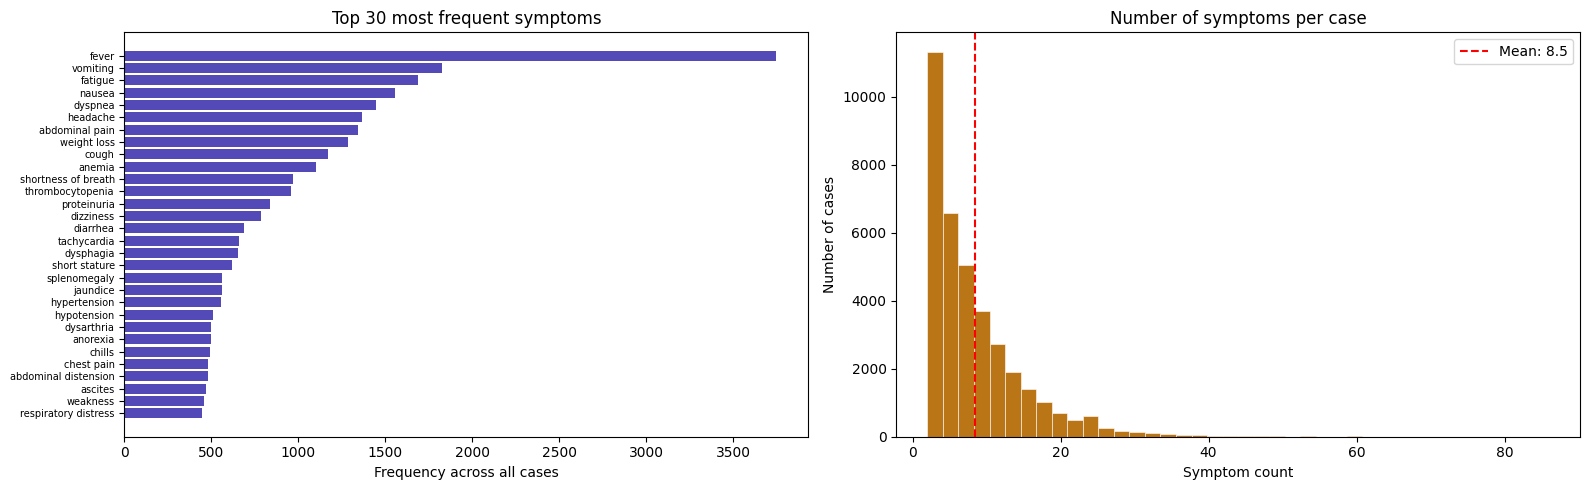

✓ Plot 2 saved

Top 10 symptoms:
  fever                                    3744
  vomiting                                 1827
  fatigue                                  1685
  nausea                                   1557
  dyspnea                                  1444
  headache                                 1366
  abdominal pain                           1340
  weight loss                              1284
  cough                                    1172
  anemia                                   1103


In [3]:
# Parse symptom lists
all_symptoms = []
for sym_str in df['symptoms']:
    try:
        syms = ast.literal_eval(sym_str)
        all_symptoms.extend([s.lower().strip() for s in syms])
    except:
        pass

symptom_counts = Counter(all_symptoms)
top_symptoms   = symptom_counts.most_common(30)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 30 symptoms bar chart
sym_names = [s[0][:35] for s in top_symptoms]
sym_vals  = [s[1] for s in top_symptoms]
axes[0].barh(range(len(sym_names)), sym_vals, color='#534AB7')
axes[0].set_yticks(range(len(sym_names)))
axes[0].set_yticklabels(sym_names, fontsize=7)
axes[0].set_title('Top 30 most frequent symptoms')
axes[0].set_xlabel('Frequency across all cases')
axes[0].invert_yaxis()

# Symptoms per case distribution
axes[1].hist(df['num_symptoms'].values, bins=40,
             color='#BA7517', edgecolor='white', linewidth=0.4)
axes[1].axvline(df['num_symptoms'].mean(), color='red',
                linestyle='--', linewidth=1.5,
                label=f"Mean: {df['num_symptoms'].mean():.1f}")
axes[1].set_title('Number of symptoms per case')
axes[1].set_xlabel('Symptom count')
axes[1].set_ylabel('Number of cases')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS}/day2_symptom_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Plot 2 saved")
print(f"\nTop 10 symptoms:")
for sym, count in top_symptoms[:10]:
    print(f"  {sym:<40} {count}")

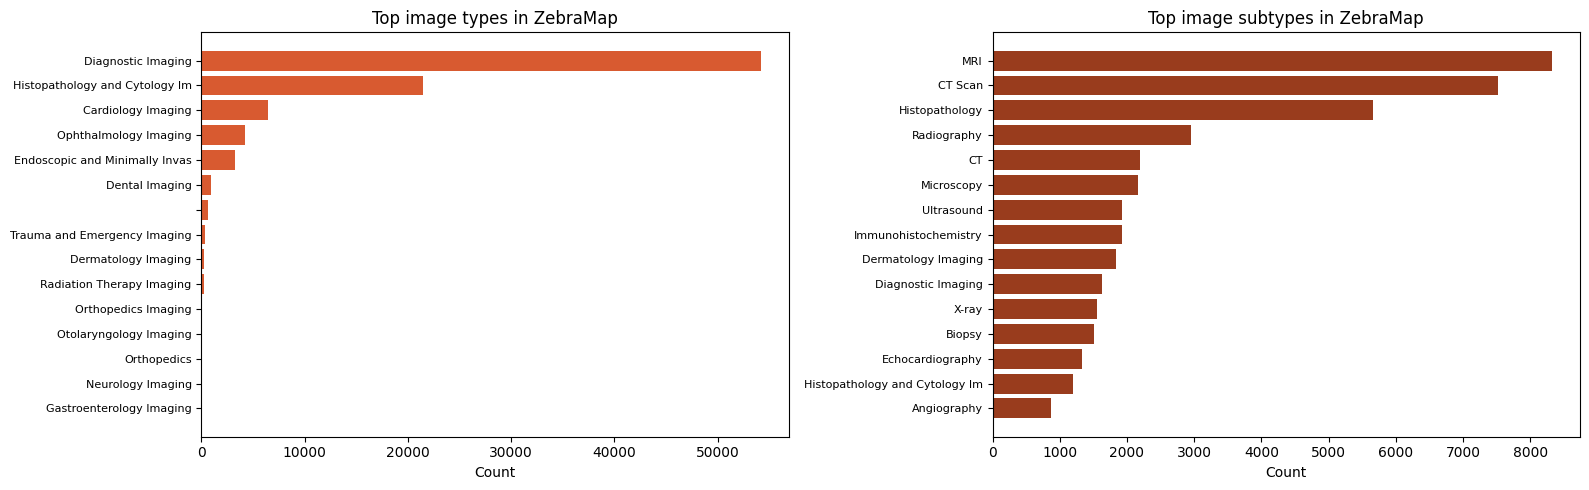

✓ Plot 3 saved


In [4]:
# Parse image types
image_types   = []
image_subtypes = []

for img_str in df['images']:
    try:
        imgs = ast.literal_eval(img_str)
        for img in imgs:
            if 'type' in img:
                image_types.append(img['type'])
            if 'subtype' in img:
                image_subtypes.append(img['subtype'])
    except:
        pass

type_counts    = Counter(image_types).most_common(15)
subtype_counts = Counter(image_subtypes).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Image types
t_names = [t[0][:30] for t in type_counts]
t_vals  = [t[1] for t in type_counts]
axes[0].barh(range(len(t_names)), t_vals, color='#D85A30')
axes[0].set_yticks(range(len(t_names)))
axes[0].set_yticklabels(t_names, fontsize=8)
axes[0].set_title('Top image types in ZebraMap')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# Image subtypes
st_names = [t[0][:30] for t in subtype_counts]
st_vals  = [t[1] for t in subtype_counts]
axes[1].barh(range(len(st_names)), st_vals, color='#993C1D')
axes[1].set_yticks(range(len(st_names)))
axes[1].set_yticklabels(st_names, fontsize=8)
axes[1].set_title('Top image subtypes in ZebraMap')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f"{RESULTS}/day2_image_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 3 saved")

In [5]:
print("=" * 50)
print("EXP1 SPLIT ANALYSIS (5-10% scarcity)")
print("=" * 50)

exp1_disease_counts = exp1_train['disease_name'].value_counts()

print(f"Total samples     : {len(exp1_train)}")
print(f"Unique diseases   : {exp1_train['disease_name'].nunique()}")
print(f"Min per class     : {exp1_disease_counts.min()}")
print(f"Max per class     : {exp1_disease_counts.max()}")
print(f"Mean per class    : {exp1_disease_counts.mean():.1f}")

print(f"\nSamples per class distribution:")
print(f"  1 sample  : {(exp1_disease_counts == 1).sum()} diseases")
print(f"  2 samples : {(exp1_disease_counts == 2).sum()} diseases")
print(f"  3 samples : {(exp1_disease_counts == 3).sum()} diseases")
print(f"  4+ samples: {(exp1_disease_counts >= 4).sum()} diseases")

# Verify symptom_text column is ready for NLP
print(f"\nSymptom text sample:")
print(f"  '{exp1_train['symptom_text'].iloc[0][:100]}...'")
print(f"\nLabel range: {exp1_train['label'].min()} → {exp1_train['label'].max()}")
print(f"Unique labels in exp1: {exp1_train['label'].nunique()}")

EXP1 SPLIT ANALYSIS (5-10% scarcity)
Total samples     : 514
Unique diseases   : 49
Min per class     : 5
Max per class     : 24
Mean per class    : 10.5

Samples per class distribution:
  1 sample  : 0 diseases
  2 samples : 0 diseases
  3 samples : 0 diseases
  4+ samples: 49 diseases

Symptom text sample:
  'patent ductus arteriosus (pda) [SEP] pulmonary valve stenosis [SEP] patent foramen ovale [SEP] hypot...'

Label range: 7 → 718
Unique labels in exp1: 49


In [ ]:
# Install transformers (pre-installed on Colab but ensure latest)
import subprocess
subprocess.run(["pip", "install", "transformers", "torch", "-q"])

from transformers import AutoTokenizer
import torch

print(f"PyTorch version     : {torch.__version__}")
print(f"GPU available       : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name            : {torch.cuda.get_device_name(0)}")

# Load BioBERT tokenizer
print("\nLoading BioBERT tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.2")
print("✓ BioBERT tokenizer loaded")

# Quick tokenization test
sample_text = exp1_train['symptom_text'].iloc[0]
tokens = tokenizer(
    sample_text,
    max_length=128,
    truncation=True,
    padding='max_length',
    return_tensors='pt'
)

print(f"\nTokenization test:")
print(f"  Input text   : '{sample_text[:80]}...'")
print(f"  input_ids    : {tokens['input_ids'].shape}")
print(f"  attention_mask: {tokens['attention_mask'].shape}")

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

class SymptomDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts  = df['symptom_text'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids'     : encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Build datasets
train_dataset = SymptomDataset(exp1_train, tokenizer)
test_dataset  = SymptomDataset(full_test,  tokenizer)

# Build dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print("✓ Dataset and DataLoader ready")
print(f"  Train batches : {len(train_loader)}")
print(f"  Test batches  : {len(test_loader)}")

# Sanity check — one batch
batch = next(iter(train_loader))
print(f"\nOne batch:")
print(f"  input_ids shape     : {batch['input_ids'].shape}")
print(f"  attention_mask shape: {batch['attention_mask'].shape}")
print(f"  labels shape        : {batch['label'].shape}")
print(f"  label sample        : {batch['label'][:5].tolist()}")

✓ Dataset and DataLoader ready
  Train batches : 33
  Test batches  : 334

One batch:
  input_ids shape     : torch.Size([16, 128])
  attention_mask shape: torch.Size([16, 128])
  labels shape        : torch.Size([16])
  label sample        : [37, 400, 513, 56, 707]


In [8]:
summary = {
    "day": 2,
    "eda": {
        "total_cases": len(df),
        "unique_diseases": df['disease_name'].nunique(),
        "top_symptom": top_symptoms[0][0],
        "top_image_type": type_counts[0][0],
        "exp1_unique_diseases": exp1_train['disease_name'].nunique(),
        "exp1_min_per_class": int(exp1_disease_counts.min()),
        "exp1_max_per_class": int(exp1_disease_counts.max())
    },
    "nlp_setup": {
        "model": "dmis-lab/biobert-base-cased-v1.2",
        "max_length": 128,
        "batch_size": 16,
        "train_batches": len(train_loader),
        "test_batches": len(test_loader),
        "num_classes": len(le.classes_)
    },
    "status": "Day 2 complete — EDA done, BioBERT loaded, DataLoader ready"
}

with open(f"{RESULTS}/day2_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("=" * 50)
print("DAY 2 COMPLETE ✓")
print("=" * 50)
print(f"  EDA plots saved     : 3 plots in results/")
print(f"  BioBERT loaded      : ✓")
print(f"  DataLoader ready    : ✓")
print(f"  Train batches       : {len(train_loader)}")
print(f"  Test batches        : {len(test_loader)}")
print(f"  Next → Day 3: Train BioBERT classifier on exp1 (514 samples)")

DAY 2 COMPLETE ✓
  EDA plots saved     : 3 plots in results/
  BioBERT loaded      : ✓
  DataLoader ready    : ✓
  Train batches       : 33
  Test batches        : 334
  Next → Day 3: Train BioBERT classifier on exp1 (514 samples)
